In [1]:
import cellrank as cr
import scanpy as sc

sc.settings.set_figure_params(frameon=False, dpi=100)
cr.settings.verbosity = 2

In [2]:
import sys
import warnings

warnings.simplefilter("ignore", category=UserWarning)

In [81]:
adata = sc.read('D:/scLT/Weinreb/0814/desc246.1/anndata2cellrank.h5ad')

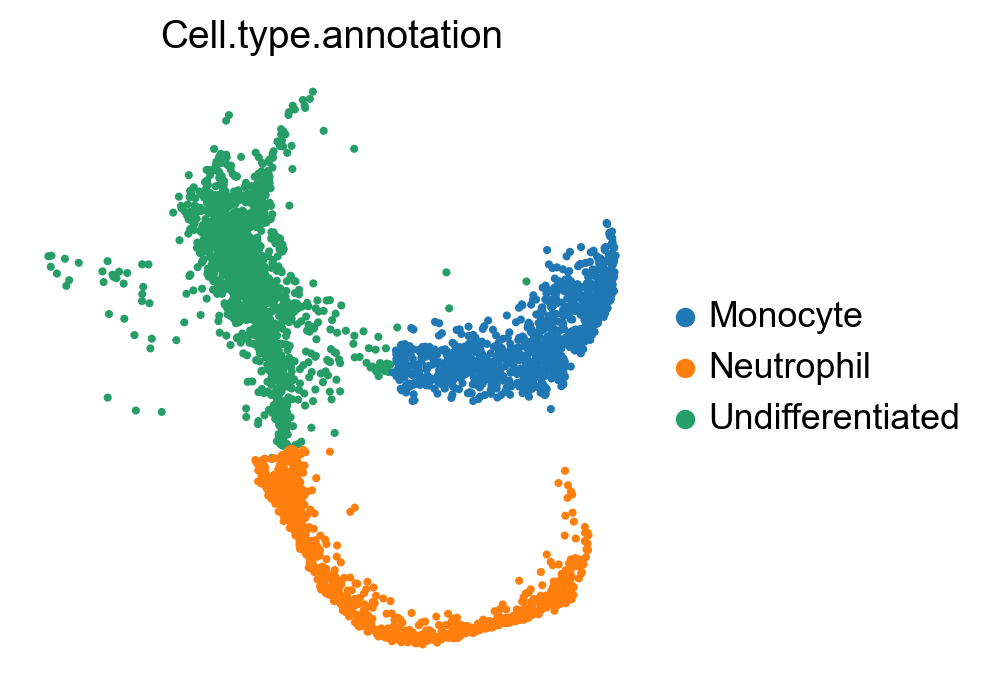

In [82]:
sc.pl.embedding(adata, basis="spring", color=["Cell.type.annotation"])

In [83]:
from cellrank.kernels import PseudotimeKernel

pk = PseudotimeKernel(adata, time_key="palantir_pseudotime")

In [84]:
pk.compute_transition_matrix()

Computing transition matrix based on pseudotime


  0%|          | 0/3509 [00:00<?, ?cell/s]

    Finish (0:00:00)


PseudotimeKernel[n=3509, dnorm=False, scheme='hard', frac_to_keep=0.3]

Simulating `100` random walks of maximum length `878`


  0%|          | 0/100 [00:00<?, ?sim/s]

    Finish (0:00:05)
Plotting random walks


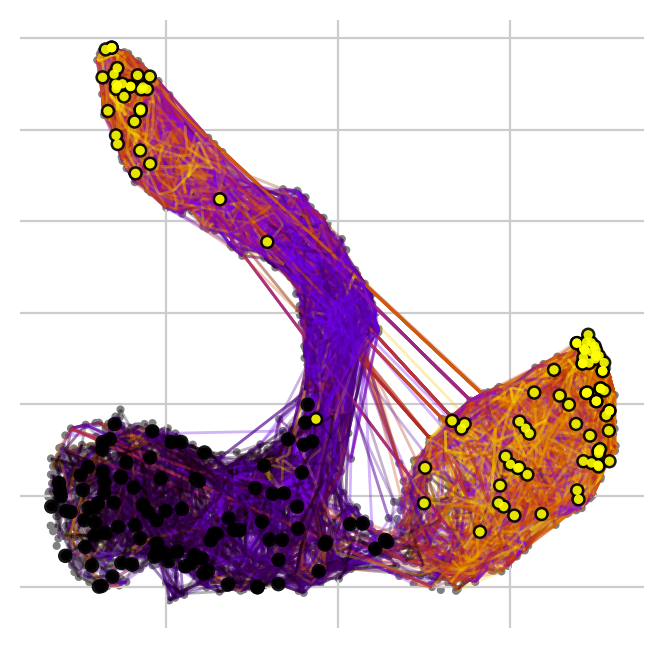

In [85]:
pk.plot_random_walks(
    seed=0,
    #n_sims=100,
    start_ixs={"Cell.type.annotation": "Undifferentiated"},
    basis="umap",
    legend_loc="right",
    #dpi=150,
)

Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:00)


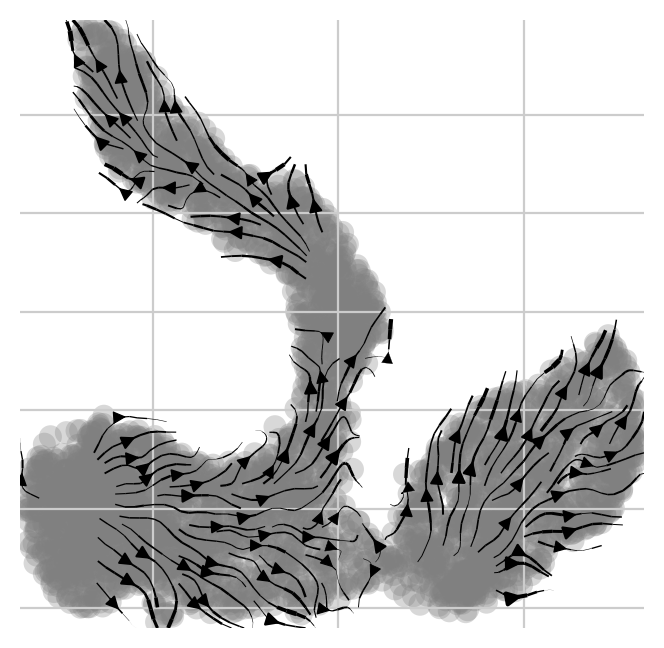

In [86]:
pk.plot_projection(basis="umap", recompute=True)

In [87]:
g = cr.estimators.GPCCA(pk)
print(g)

GPCCA[kernel=PseudotimeKernel[n=3509], initial_states=None, terminal_states=None]


In [88]:
g.fit(cluster_key="Cell.type.annotation", n_states=3)

Computing Schur decomposition
Adding `adata.uns['eigendecomposition_fwd']`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:10)
Computing `3` macrostates
Adding `.macrostates`
       `.macrostates_memberships`
       `.coarse_T`
       `.coarse_initial_distribution
       `.coarse_stationary_distribution`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:00)


GPCCA[kernel=PseudotimeKernel[n=3509], initial_states=None, terminal_states=None]

In [89]:
g.macrostates

cell13177     NaN
cell13200     NaN
cell13211     NaN
cell13257     NaN
cell13259     NaN
             ... 
cell130700    NaN
cell130805    NaN
cell130812    NaN
cell130832    NaN
cell130837    NaN
Length: 3509, dtype: category
Categories (3, object): ['Undifferentiated', 'Neutrophil', 'Monocyte']

Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`


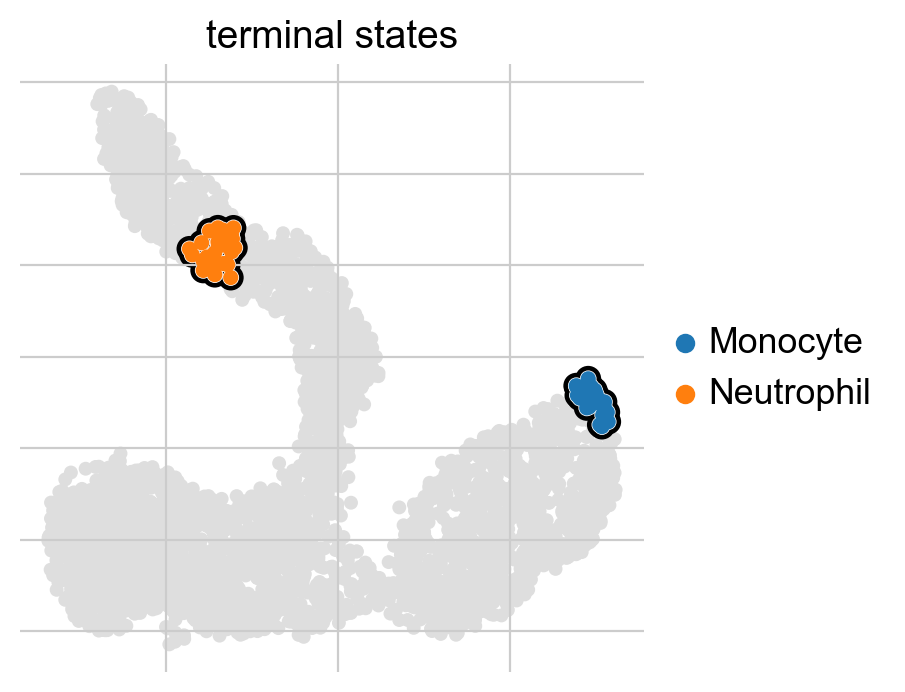

In [90]:
g.set_terminal_states(states=['Monocyte', 'Neutrophil'])
g.plot_macrostates(which="terminal", legend_loc="right", size=100)

Computing fate probabilities


  0%|          | 0/2 [00:00<?, ?/s]

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:00:00)


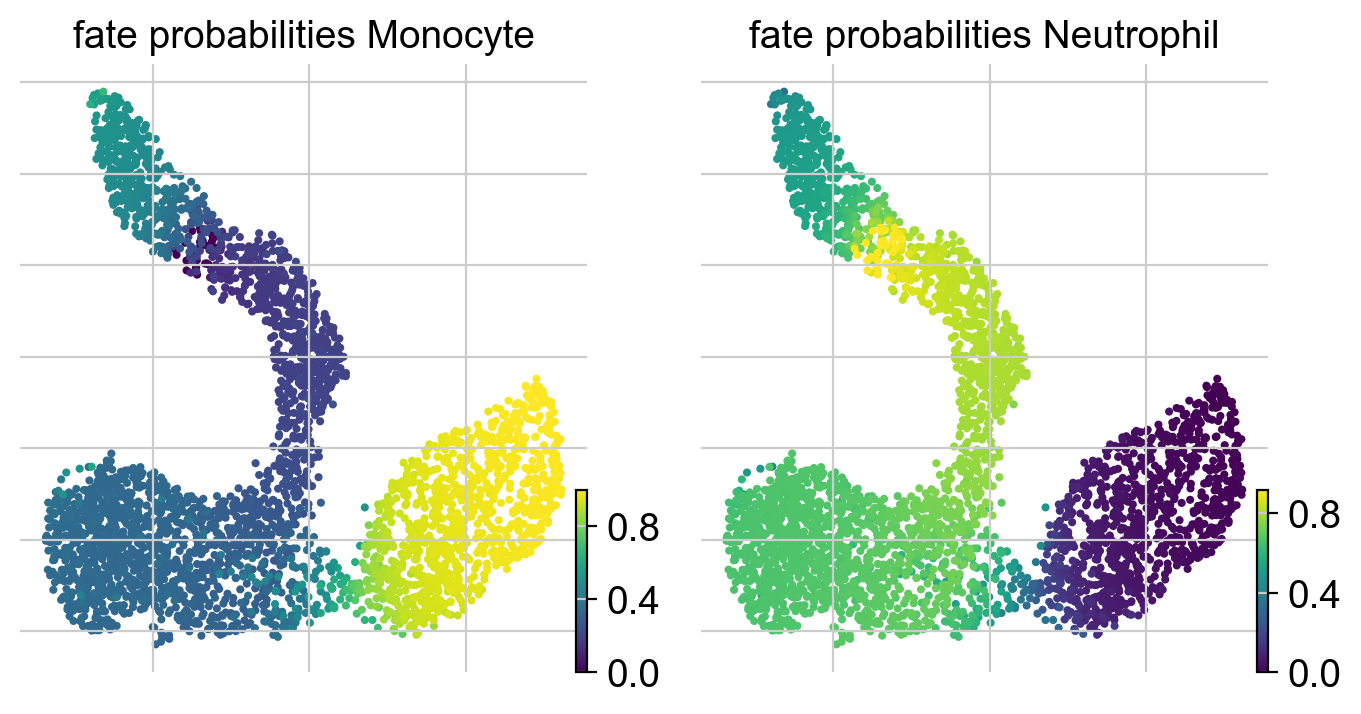

In [91]:
g.compute_fate_probabilities()
g.plot_fate_probabilities(same_plot=False)

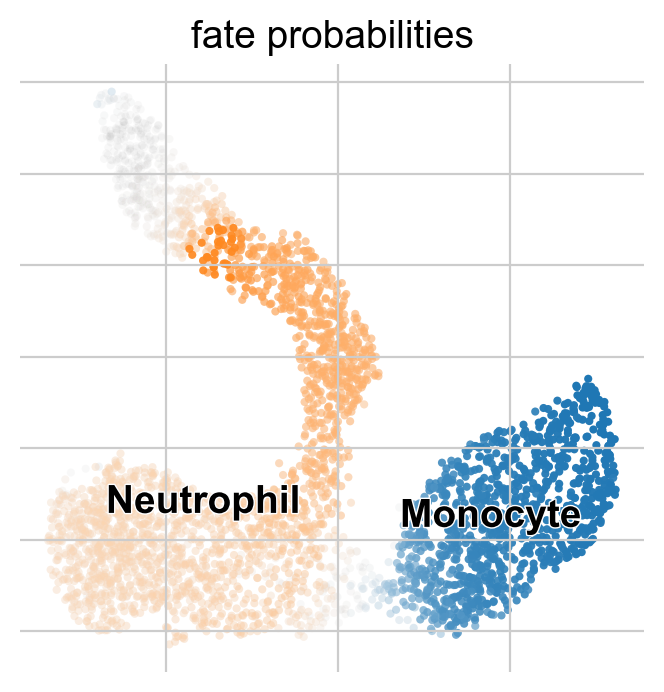

In [92]:
g.plot_fate_probabilities(same_plot=True)

In [93]:
g.fate_probabilities

Monocyte,Neutrophil
0.577009,0.422983
0.338588,0.661400
0.328974,0.671015
0.339528,0.660460
0.221280,0.778706
0.288376,0.711611
0.332906,0.667082
0.295007,0.704981
0.223582,0.776404
0.329406,0.670582


In [94]:
import pandas as pd
fate = pd.DataFrame(g.fate_probabilities)
adata.obs['Monocyte_fate'] = fate[0].values
adata.obs['Neutrophil_fate'] = fate[1].values
adata.obs['fate_bias'] = fate[0].values/(fate[0].values + fate[1].values)

In [95]:
# extract fate bias and ground truth
adata_obs_subset = adata.obs.loc[:, ['ground_truth', 'fate_bias','Cell.type.annotation']]

# extract undifferentiated cells
adata_obs_subset_undiff = adata_obs_subset[adata_obs_subset['Cell.type.annotation'] == 'Undifferentiated']

In [96]:
adata_obs_subset_undiff.to_csv('D:/scLT/Weinreb/0814/desc246.1/cellrank.res.csv')